# Lab session 1: Dimension reduction with Python

Dimension reduction is widely used in applied ML tasks for **visualization** as well as part of the pipeline for **scientific discovery**. In this lab, you will learn some standard methods for dimension reduction, and good practices in applied problems using manifold learning. 

In [166]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import tqdm 
import pandas as pd

In [167]:
from course_checks import grader

## Part 1. Deep dive on t-SNE and UMAP dimension reduction methods

For this exercise, we will use the baby MNIST dataset that you can load with `scikit-learn`. 

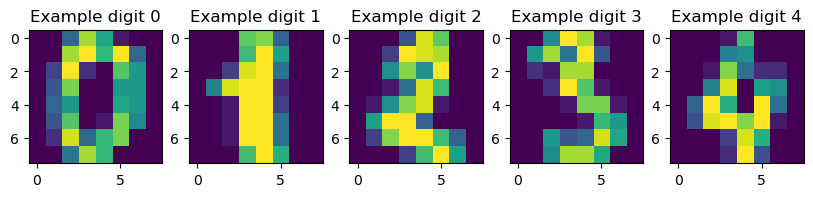

In [326]:
# Run this cell to load the data
from sklearn.datasets import load_digits
data = load_digits()
X, y = data['data'], data['target']

fig, ax = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    ax[i].imshow(X[i,:].reshape(8,8))
    ax[i].set_title(f'Example digit {y[i]}')

### Question 0. Apply PCA to MNIST data
Apply PCA with `sklearn.decomposition`'s `PCA` in function in 2 dimensions. Plot the data on the embedding colored by true classes. Is it a satisfying embedding? What would be better? 

In [169]:
# TODO: apply PCA function 
# TODO: plot the embedding colored by classes

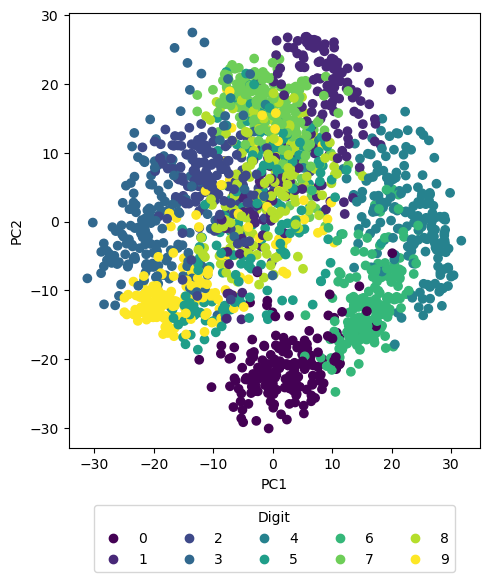

In [170]:
from sklearn.decomposition import PCA 
# PCA Embedding
Z = PCA(n_components=2).fit_transform(X)
# Plot
fig, ax = plt.subplots(figsize=(5,6))
scatter = ax.scatter(Z[:,0], Z[:, 1], c=pd.Categorical(y).codes)
handles, _ = scatter.legend_elements()
ax.set_ylabel('PC2')
ax.set_xlabel("PC1")
ax.legend(handles, pd.Categorical(y).categories, title="Digit", ncol=5, loc='lower center',bbox_to_anchor=(0.,-0.3, 1, -0.))
fig.tight_layout()

## Question 1. A simplified t-SNE implementation 
What does t-SNE do? t-SNE maps the higher dimensional original data onto a lower dimensional embedding while preserving the pairwise similarities, $p_{ij}$ on the original space, $q_{ij}$ on the embedding space. 
* The original data's similarities are approximated with a normalized RBF kernel where the kernel width (perplexity hyperparameter) controls how "localized" the fitted kernel is - if $\sigma^2$ is large, then the kernel includes more neighbors, if small, it will tighten the kernel around each observation). 


$$
p_{j\mid i} =
\frac{\exp\left(-\lVert x_i-x_j\rVert^2/(2\sigma^2)\right)}
{\sum_{k\ne i}\exp\left(-\lVert x_i-x_k\rVert^2/(2\sigma^2)\right)},
\qquad p_{i\mid i}=0.
$$

After normalization and symmetrizing: $p_{ij}=\frac{p_{j\mid i}+p_{i\mid j}}{2n}.$


* The embedded data's similarity uses a Student-t kernel with 1 degree of freedom (essentially a Cauchy kernel) instead of RBF. This allows the embedding space to preserve distances of points **already close in original space**. 
$$
q_{ij}=
\frac{(1+\lVert z_i-z_j\rVert^2)^{-1}}
{\sum_{k\ne \ell}(1+\lVert z_k-z_\ell\rVert^2)^{-1}},
\qquad q_{ii}=0.
$$

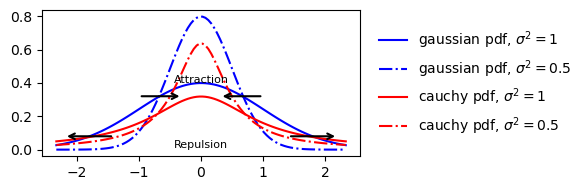

In [171]:
from scipy.stats import cauchy, norm 

x = np.linspace(norm.ppf(0.01), norm.ppf(0.99), 100)
fig, ax = plt.subplots(figsize=(6,2))
ax.plot(x, norm.pdf(x), 'b-', label=f'gaussian pdf, $\sigma^2=1$')
ax.plot(x, norm.pdf(x, scale=0.5), 'b-.', label=f'gaussian pdf, $\sigma^2=0.5$')
ax.plot(x, cauchy.pdf(x, scale=1), 'r-', label=f'cauchy pdf, $\sigma^2=1$')
ax.plot(x, cauchy.pdf(x, scale=0.5), 'r-.', label=f'cauchy pdf, $\sigma^2=0.5$')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
# Contraction toward the center
ax.annotate('', xy=(0.3, 0.32), xytext=(1.0, 0.32), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(-0.3, 0.32), xytext=(-1.0, 0.32), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(0, 0.39, 'Attraction', ha='center', va='bottom', fontsize=8)

# Repulsion toward the tails
ax.annotate('', xy=(2.2, 0.08), xytext=(1.4, 0.08), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(-2.2, 0.08), xytext=(-1.4, 0.08), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(0, 0.06, 'Repulsion', ha='center', va='top', fontsize=8)
fig.tight_layout()


a) *Can we preserve all distances?* 

b) We are starting with computing the similarities in original dimension space and in embedding space.

In [172]:
print("No we can't preserve all distances, this is the curse of dimensionality (see Johnson Lindenstrauss lemma)")

No we can't preserve all distances, this is the curse of dimensionality (see Johnson Lindenstrauss lemma)


In [210]:
def original_similarities(X, sigma=1.0):
    # TODO: Compute RBF kernel for similarities 
    raise NotImplementedError("Complete original_similarities")

def embedding_similarities(Z):
    # TODO: Compute Cauchy kernel for similarities 
    raise NotImplementedError("Complete embedding_similarities")

In [195]:
from scipy.spatial.distance import pdist
def original_similarities(X, sigma=1.0):
    n = X.shape[0]
    D_2= squareform(pdist(X, 'sqeuclidean')) # squared distance
    P = np.exp(-D_2 / (2*sigma**2))
    np.fill_diagonal(P, 0) # p_{ii} = 0
    P /= np.maximum(P.sum(axis=1, keepdims=True), 1e-12) # normalize RBF, jitter for division by 0
    P = (P + P.T) / (2*n) # symmetrize    
    return P

In [196]:
def embedding_similarities(Z):
    D_2 = squareform(pdist(Z, 'sqeuclidean')) 
    Q = 1/(1+D_2) 
    np.fill_diagonal(Q, 0)
    Q /= Q.sum() # normalize density
    return Q


c) t-SNE optimizes the embedding where $Q$ lives on by minimising the KL divergence between $P$ and $Q$. Essentially, use gradient descent on
$$\min_{z} \text{KL}(P||Q) = \min_{z} \sum_{i,j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

*What are possible problems with this optimization problem?* 

d) Derive the gradient of the objective and use gradient descent to solve the optimization problem. 


In [197]:
from IPython.display import display, Math
display(Math(r'\frac{\partial C}{\partial z_i} = 4 \sum_{j \neq i} (z_i-z_j)'
    r'(1+\|z_i-z_j\|^2)^{-1}(p_{ij}-q_{ij})'))

<IPython.core.display.Math object>

In [212]:
def compute_gradient(X, Z, P, Q): 
    # TODO: compute gradient
    raise NotImplementedError("Complete compute_gradient")

def gradient_descent(X, **kwargs):
    # TODO: implement gradient descent for the problem
    raise NotImplementedError("Complete gradient_descent")

In [198]:
def compute_gradient(P, Q, Z):
    n, d = Z.shape
    D_2 = squareform(pdist(Z, 'sqeuclidean'))
    pairwise_diff = Z[:, np.newaxis, :] - Z[np.newaxis, : ,:] # pairwise diffs
    grad = 4 * (P - Q)[:, :, np.newaxis] * pairwise_diff * 1 / (1 + D_2[:, :, np.newaxis]) 
    return np.sum(grad, axis=1)

In [199]:
def gradient_descent(X, sigma, Z_init, learning_rate, max_iter, tol=1e-12):
    P = original_similarities(X, sigma)
    Z = Z_init 
    loss_init = np.inf
    for iter in range(max_iter):
        Q = embedding_similarities(Z)
        loss = np.sum(P * np.log((P+1e-12)/(Q+1e-12)))
        if abs(loss_init - loss) < tol:
            print(f"Converged at iteration {iter}: loss={loss:.6f}")
            break

        grad = compute_gradient(P, Q, Z)
        Z -= learning_rate * grad
        if iter % 100 == 0 or iter == max_iter - 1:
            print(f"Iteration {iter}: loss = {loss:.6f}")
        loss_init = loss
    return Z

d) Write up the `tsne` function by compiling all the steps. Apply it to the baby MNIST data. 


*Hints:*
-  *you might want to use a high learning rate 500 or more, the learning rate for t-SNE is usually in the range [10.0, 1000.0].*
-  *the initialized embedding points need to be sampled from a centered distribution with very small variance.*

In [213]:
def tsne(X, **kwargs):
    # TODO: complete the function
    raise NotImplementedError("Complete tsne")

In [ ]:
def tsne(X, n_components=2, sigma=1, learning_rate=0.1, max_iter=5000, init_std=1e-4, tol=1e-12, random_state=42):
    n = X.shape[0]
    rng = np.random.default_rng(random_state)
    Z_init = rng.normal(0, init_std, size=(n, n_components))
    Z = gradient_descent(X, sigma, Z_init, learning_rate, max_iter, tol)
    return Z

In [ ]:
# TODO: apply solution on MNIST and visualize the solution 

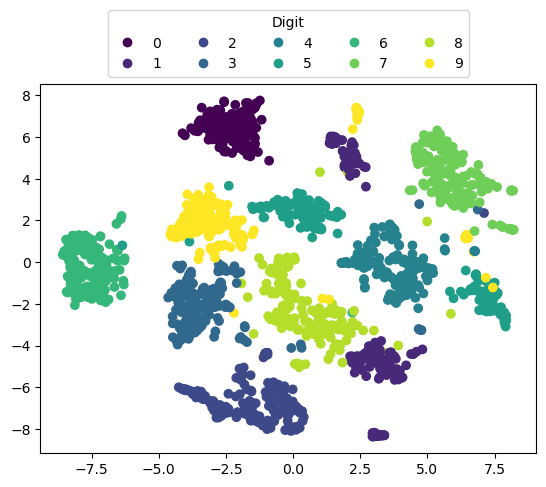

In [206]:
Z_hand = tsne(X, n_components=2, sigma=10, learning_rate=100, max_iter=500, random_state=42)
scatter = plt.scatter(Z_hand[:, 0], Z_hand[:, 1], c=y)
handles, _ = scatter.legend_elements()
plt.legend(handles, pd.Categorical(y).categories, title="Digit", ncol=5, loc='lower center',bbox_to_anchor=(0., 1, 1, -0.))


## Question 2. Apply t-SNE out of the box
t-SNE is implemented in `sklearn.manifold`. Note that our version of `tsne` fixed the parameter `sigma`. The original `tsne` varies the bandwidth to match the required perplexity measure. Apply to obtain the 2D embedding and compare with your implementation.

In [ ]:
# TODO: Apply t-SNE out of the box to MNIST data
# TODO: Plot next to hand derived t-SNE. 

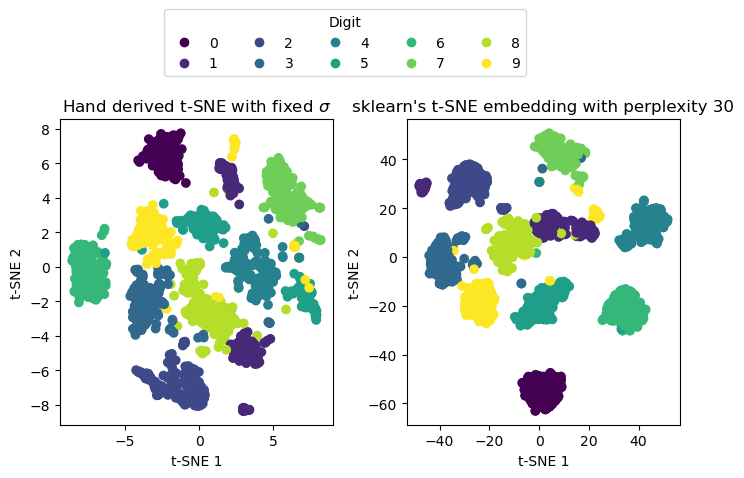

In [209]:
from sklearn.manifold import TSNE

Z_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X)

fig, ax = plt.subplots(1, 2, figsize=(7, 4))
ax[0].scatter(Z_hand[:,0], Z_hand[:, 1], c=pd.Categorical(y).codes)
scatter = ax[1].scatter(Z_tsne[:,0], Z_tsne[:, 1], c=pd.Categorical(y).codes)
handles, _ = scatter.legend_elements()
for i in range(2):
    ax[i].set_ylabel('t-SNE 2')
    ax[i].set_xlabel("t-SNE 1")
ax[0].set_title(f"Hand derived t-SNE with fixed $\sigma$")
ax[1].set_title("sklearn's t-SNE embedding with perplexity 30")
fig.legend(handles, pd.Categorical(y).categories, title="Digit", ncol=5, loc='lower center',bbox_to_anchor=(0., 1, 1, -0.))
fig.tight_layout()

## Question 3. UMAP 

For this part, you will need to install the umap package: run in your environment the following command:
```{bash}
pip install umap-learn
```

UMAP is a technique similar to t-SNE in principle, but it focuses even further on local neighborhood:
1)  by adding a weighted k-nearest neighbor graph to the general distances: $p_{ij} \propto \exp\big(-\frac{1}{2\sigma^2}\sum_{i \in ne_k(j)} ||x_i-x_j||^2\big)$. 
2)  by using a generalized Cauchy kernel $q(z_i, z_j) = (1 + a||z_i-z_j||^{2b})^{-1}$ with $a > 1, b< 1$ which allows to control for thicker tails.


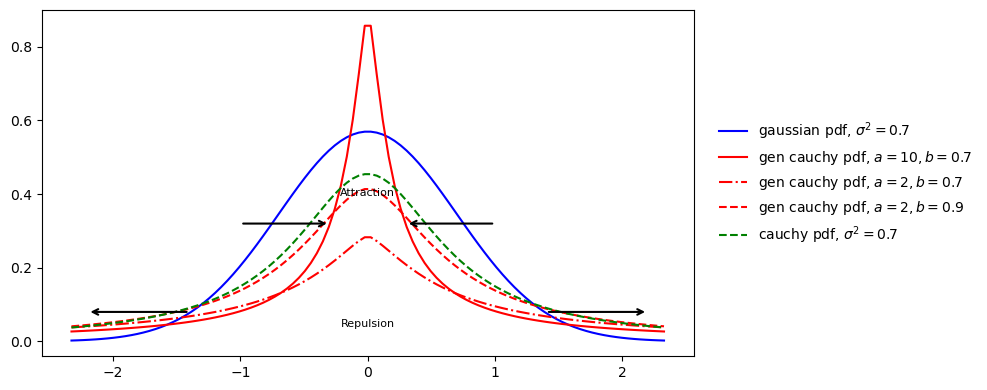

In [232]:
from scipy.stats import rv_continuous

class gen_cauchy_gen(rv_continuous):
    def _argcheck(self, a, b):
        # Conditions required for a valid, integrable PDF
        return (a > 1) & (b < 1) & (b > 0.5)
    def _pdf(self, x, a, b):
        normalizer = (b * np.power(a, 1 / (2 * b)) * np.sin(np.pi / (2 * b)) / np.pi)
        return normalizer / (1 + a * np.power(np.abs(x), 2 * b))
gencauchy = gen_cauchy_gen(name="gencauchy", shapes="a, b")

x = np.linspace(norm.ppf(0.01), norm.ppf(0.99), 100)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(x, norm.pdf(x, scale=0.7), 'b-', label=f'gaussian pdf, $\sigma^2=0.7$')
ax.plot(x, gencauchy.pdf(x, a=10, b=0.7), 'r-', label=f'gen cauchy pdf, $a=10, b=0.7$')
ax.plot(x, gencauchy.pdf(x, a=2, b=0.7), 'r-.', label=f'gen cauchy pdf, $a=2, b=0.7$')
ax.plot(x, gencauchy.pdf(x, a=2, b=0.9), 'r--', label=f'gen cauchy pdf, $a=2, b=0.9$')
ax.plot(x, cauchy.pdf(x, scale=0.7), 'g--', label=f'cauchy pdf, $\sigma^2= 0.7$')

ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
# Contraction toward the center
ax.annotate('', xy=(0.3, 0.32), xytext=(1.0, 0.32), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(-0.3, 0.32), xytext=(-1.0, 0.32), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(0, 0.39, 'Attraction', ha='center', va='bottom', fontsize=8)

# Repulsion toward the tails
ax.annotate('', xy=(2.2, 0.08), xytext=(1.4, 0.08), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(-2.2, 0.08), xytext=(-1.4, 0.08), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(0, 0.06, 'Repulsion', ha='center', va='top', fontsize=8)
fig.tight_layout()

Apply umap embedding to the baby MNIST data. Note that umap has the following hyperparameters: 
* `n_neighbors` used to compute the $k$-NN graph. 
* `min_dist` a parameter that controls the parameters $(a, b)$ from the generalized Cauchy distribution of the embedding points. 

a) Fit a 2-D UMAP using 5, 15, 50, 200 neighbors while holding everything else fixed, you can use the default `min_dist` value of 0.1. Visualize the results.

In [ ]:
!pip install umap-learn

In [296]:
# TODO: plot the results of the embedding with the 4 values of n_neighbors

4it [00:11,  2.95s/it]


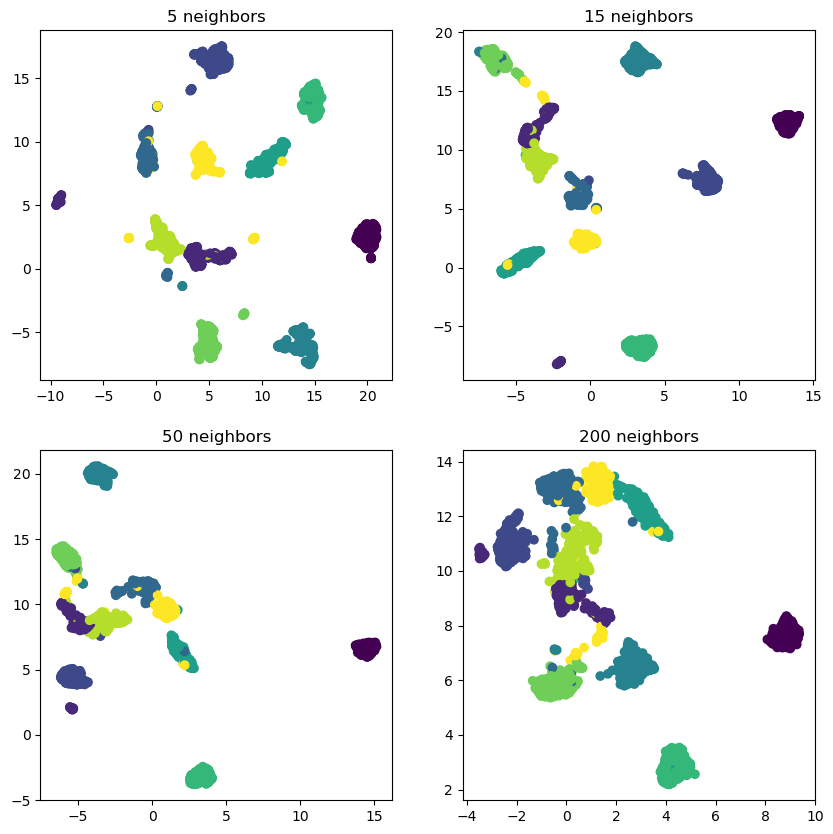

In [237]:
import umap
import tqdm
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.flatten()
for i, k in tqdm.tqdm(enumerate([5, 15, 50, 200])):
    f = umap.UMAP(n_neighbors=k, n_components=2, min_dist=0.1, random_state=42)
    Z_umap = f.fit_transform(X)
    ax[i].scatter(Z_umap[:, 0], Z_umap[:, 1],c=y)
    ax[i].set_title(f"{k} neighbors")

b) Fit a 2-D UMAP using `min_dist` with values 0, 0.1, 0.5 and 0.8 while holding `n_neighbors=20`. Visualize the results.

In [240]:
# TODO: plot the results of the embedding with the 4 values of min_dist

4it [00:09,  2.36s/it]


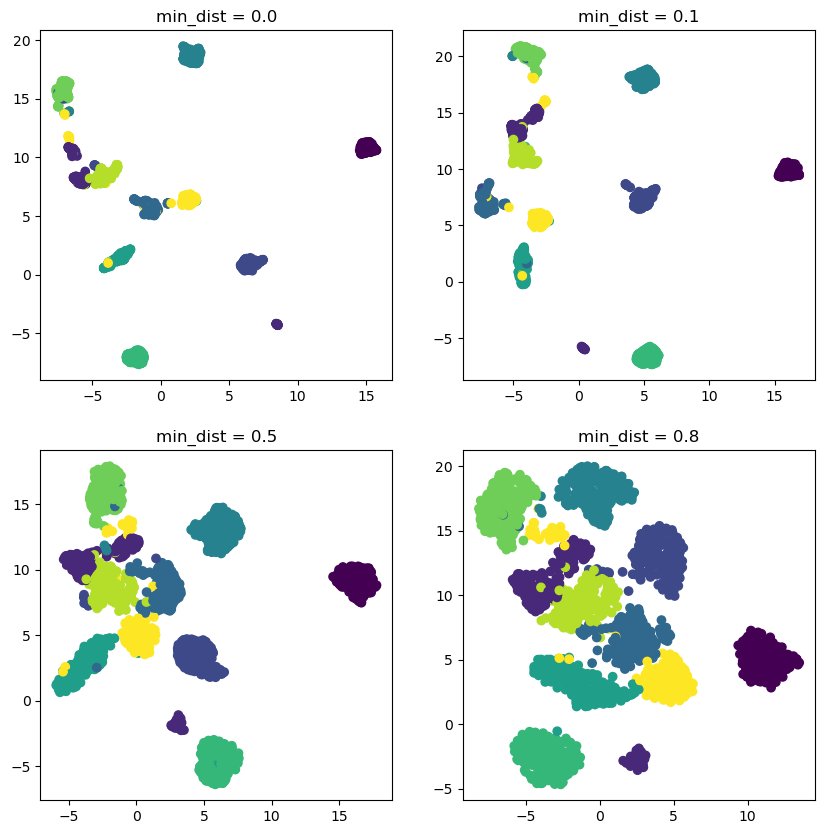

In [239]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.flatten()
for i, min_d in tqdm.tqdm(enumerate([0.0, 0.1, 0.5, 0.8])):
    f = umap.UMAP(n_neighbors=20, n_components=2, min_dist=min_d, random_state=42)
    Z_umap = f.fit_transform(X)
    ax[i].scatter(Z_umap[:, 0], Z_umap[:, 1],c=y)
    ax[i].set_title(f"min_dist = {min_d}")

c) What do you observe? What are the challenges of dimension reduction for visualization? 

## Bonus question:
If you've finished the previous parts early, you can work towards implementing the full t-SNE routine. The perplexity in the t-SNE paper is defined as $$\text{per} = 2^{H} \text{ where } H = - \sum_{ij} p_{ij} \log p_{ij}$$

1) Replace the fixed bandwidth with a binary search for observation-specific bandwidths that match a target perplexity.
2) The implementation adds *momentum* to the gradient descent. The momentum term is added to the gradient to speed up optimization and avoid local minima. Mathematically: 

$$z^{(t)} = z^{(t-1)} + \eta \frac{\partial C}{\partial z} + \underbrace{\textcolor{red}{\alpha(t) \big( z^{(t-1)}-z^{(t-2)}\big)}}_{\text{momentum } \alpha(t)}$$


# Part 2. Good practices of dimension reduction

### Question 4. Dimension reduction for data visualization

Get the additional embeddings of the usual manifold learning methods (under `sklearn.manifold`): ISOMAP, LLE, Spectral Embedding, tSNE. What are the hyperparameters for each method? Get a 2 by 5 panel showing each method + UMAP with at least 2 values of one of the main hyperparameters colored by their classes when possible. 

In [ ]:
# TODO: explore more traditional manifold embedding methods

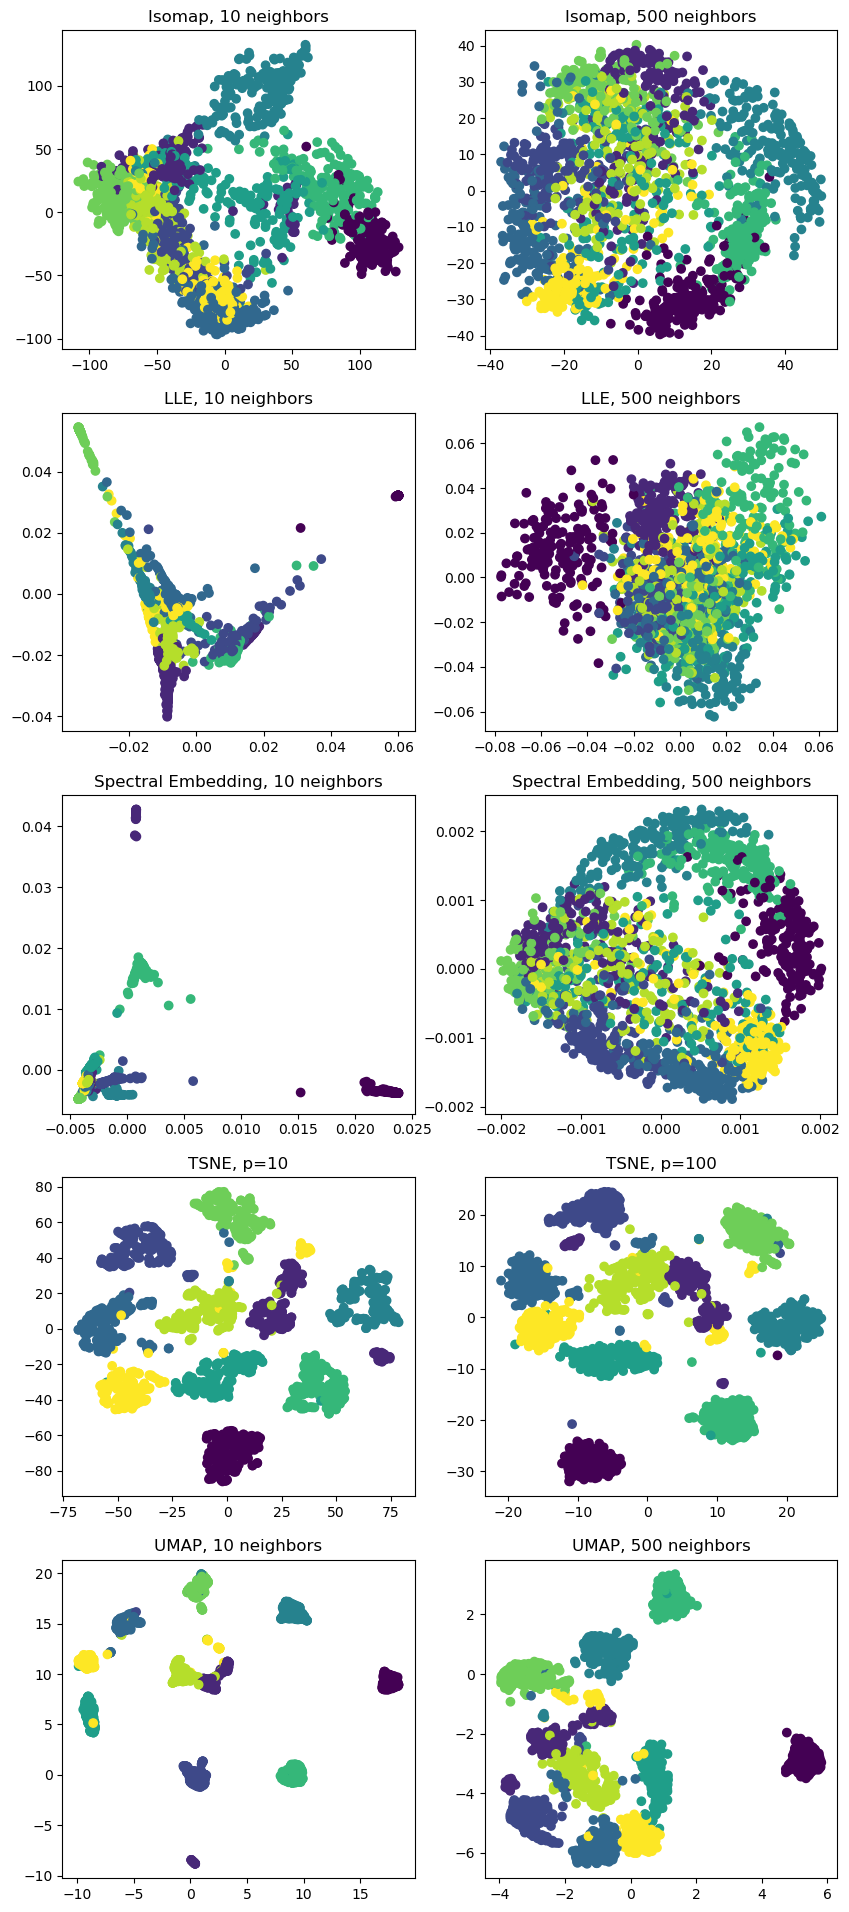

In [306]:
from sklearn.manifold import Isomap, LocallyLinearEmbedding, SpectralEmbedding, TSNE
n_neighbors = [10, 500]
perp = [10, 100]
embeddings = {}

fig, ax = plt.subplots(5, 2, figsize=(10, 24))
for i, k in enumerate(n_neighbors):
    Z_temp = Isomap(n_components=2, n_neighbors=k).fit_transform(X)
    embeddings[("Isomap", f"neighbors={k}")] = Z_temp
    ax[0, i].scatter(Z_temp[:, 0], Z_temp[:, 1], c=y)
    ax[0, i].set_title(f"Isomap, {k} neighbors")

    Z_temp = LocallyLinearEmbedding(n_components=2, n_neighbors=k, random_state=42).fit_transform(X)
    embeddings[("LLE", f"neighbors={k}")] = Z_temp
    ax[1, i].scatter(Z_temp[:, 0], Z_temp[:, 1], c=y)
    ax[1, i].set_title(f"LLE, {k} neighbors")

    Z_temp = SpectralEmbedding(n_components=2, n_neighbors=k, random_state=42).fit_transform(X)
    embeddings[("SpectralEmbedding", f"neighbors={k}")] = Z_temp
    ax[2, i].scatter(Z_temp[:, 0], Z_temp[:, 1], c=y)
    ax[2, i].set_title(f"Spectral Embedding, {k} neighbors")

    Z_temp = TSNE(n_components=2, perplexity=perp[i], random_state=42).fit_transform(X)
    embeddings[("TSNE", f"perplexity={perp[i]}")] = Z_temp
    ax[3, i].scatter(Z_temp[:, 0], Z_temp[:, 1], c=y)
    ax[3, i].set_title(f"TSNE, p={perp[i]}")

    f = umap.UMAP(n_neighbors=k, n_components=2, min_dist=0.1, random_state=42)
    Z_umap = f.fit_transform(X)
    embeddings[("UMAP", f"neighbors={k}")] = Z_umap
    ax[4, i].scatter(Z_umap[:, 0], Z_umap[:, 1],c=y)
    ax[4, i].set_title(f"UMAP, {k} neighbors")
    

    

What makes a better embedding? 

### Question 5. Comparing dimension reduction methods

Does an embedding method better preserve **local neighborhoods** or **global distances**? Define the original data distances $d_{ij} = ||X_i - X_j||_2$ and the embedding distances $\delta_{ij} = ||z_i - z_j||_2$ where $z_i = f(X_i)$ the embedded data point.  Construct the following two metrics: 
1) `global_distance_preservation`: the correlation between high-dimensional and two-dimensional pairwise distances.
Let $D = (d_{ij})$ and $\Delta=(\delta_{ij})$, the global preservation score of the dataset is:
$$\rho(D, \Delta) = \frac{Cov(D, \Delta)}{\sqrt{Var(D)Var(\Delta)}}$$
2) `local_neighborhood_preservation`: the fraction of $k$-nearest neighbors preserved where for any observation $i$, 
$$p_{k}(i) = \frac{|\{j \in ne_{k}(X_{i}) \} \cap \{ j \in ne_{k}(z_{i}) \} |}{k}.$$
And the local neighborhood score is:
$$p_k = \frac{1}{n} \sum_i p_k(i)$$
 


In [ ]:
def global_distance_preservation(X, Z):
    # TODO: take X and Z, compute pairwise distances respetively to get D and \Delta 
    # to compute \rho(d_{ij}, \delta_{ij}) across all observations pairs (i,j)
    # note that this measure is symmetric in (i,j )
    raise NotImplementedError("Complete global_distance_preservation")

def local_neighborhood_preservation(X, Z, k=10):
    # TODO: take X, Z get respective nearest k-neighbors to compute p_k
    raise NotImplementedError("Complete local_neighborhood_preservation")

In [277]:
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist, squareform

def global_distance_preservation(X, Z):
    return pearsonr(pdist(X), pdist(Z)).statistic

In [272]:
from sklearn.neighbors import NearestNeighbors

def local_neighborhood_preservation(X, Z, k=10):
    ind_X = NearestNeighbors(n_neighbors=k + 1).fit(X).kneighbors(X, return_distance=False)[:, 1:]
    ind_Z = NearestNeighbors(n_neighbors=k + 1).fit(Z).kneighbors(Z, return_distance=False)[:, 1:]
    p_k = [len(np.intersect1d(ind_X[i], ind_Z[i])) / k for i in range(X.shape[0])]
    return np.mean(p_k)

Take embeddings obtained in **Question 4** and compute the new preservation metrics for each embedding method, and both hyperparameter values. Plot the 11 points in a scatter plot with local neighborhood preservation as the y axis and global preservation as the x axis. For local neighborhood preservation, you can set $k=10$. Add the metrics for PCA.

In [ ]:
# TODO: get metrics for all 5 methods, 2 hyperparameter values

# TODO: scatter plot of 11 points along the two axes: global and local preservation

In [298]:
embeddings[("PCA", "default")] = PCA(n_components=2).fit_transform(X)

methods, parameters, local_list, global_list = [], [], [], []
for (method, parameter), Z_temp in embeddings.items():
    methods.append(method)
    parameters.append(parameter)
    local_list.append(local_neighborhood_preservation(X, Z_temp))
    global_list.append(global_distance_preservation(X, Z_temp))

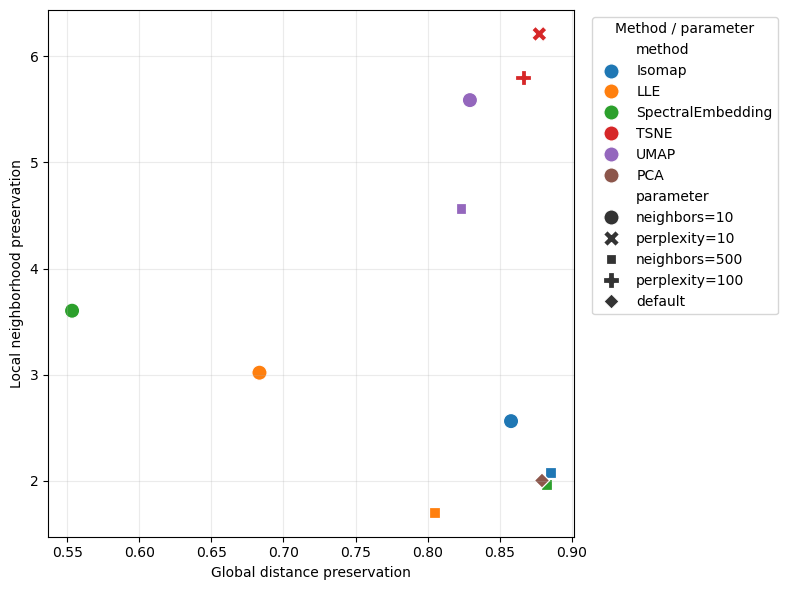

In [305]:
import seaborn as sns

df = pd.DataFrame(np.array([local_list, global_list]).T, columns = ['local', 'global'])
df["method"] = methods
df["parameter"] = parameters

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x="global", y="local", hue="method", style="parameter", s=120, ax=ax)
ax.set(xlabel="Global distance preservation", ylabel="Local neighborhood preservation")
ax.grid(alpha=0.25)
ax.legend(title="Method / parameter", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()

### Question 6. How do we choose the hyperparameters? 

We'll explore hyperparameter tuning for the `LocalLinearEmbedding` method. For starters, let's consider the neighbor grid values $k \in \{5, 15, 25, 50, 100\}$.
1) Validation via supervised downstream tasks in the presence of labels.
Apply LLE to get the manifold embedding $Z$ for each value of the neighbor hyperparameter. Use a classifier of your choice and two classification metrics to evaluate classifying the digit labels using the manifold. For each metric, plot out the classification metric against neighbor grid.  

In [345]:
# TODO: Using classification to evaluate hyperparameters

Text(0.5, 0, 'Number of neighbors')

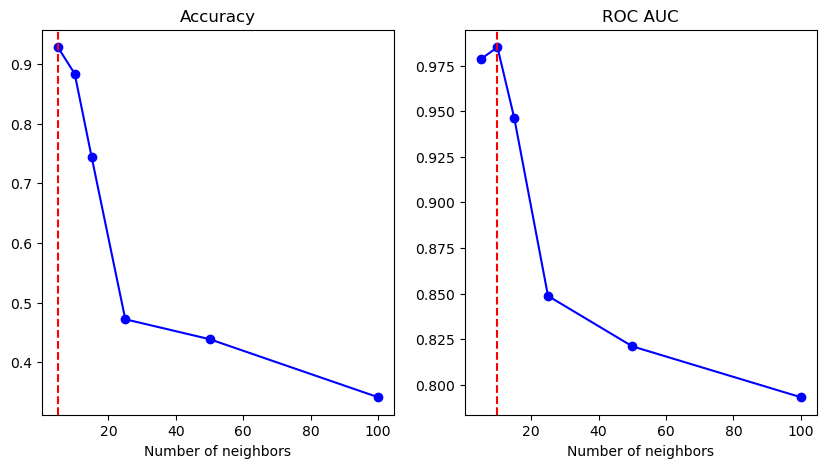

In [ ]:
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

neighbor_grid = [5, 10, 15, 25, 50, 100]
acc=[]
roc_auc=[]

for k in neighbor_grid:
    Z_lle = LocallyLinearEmbedding(n_components=2, n_neighbors = k, random_state=123).fit_transform(X)
    Z_tr, Z_ca, y_tr, y_ca = train_test_split(Z_lle, y, test_size=0.2)
    rf = RandomForestClassifier(random_state=123).fit(Z_tr, y_tr)
    rf_labels = rf.predict(Z_ca)
    acc.append(accuracy_score(y_ca, rf_labels))
    roc_auc.append(roc_auc_score(y_ca, rf.predict_proba(Z_ca), multi_class='ovr'))

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].plot(neighbor_grid, acc, 'bo-')
ax[0].axvline(neighbor_grid[np.argmax(acc)], linestyle='--', color='red')
ax[1].plot(neighbor_grid, roc_auc, 'bo-')
ax[1].axvline(neighbor_grid[np.argmax(roc_auc)], linestyle='--', color='red')
ax[0].set_title('Accuracy')
ax[0].set_xlabel('Number of neighbors')
ax[1].set_title('ROC AUC')
ax[1].set_xlabel('Number of neighbors')

2. Validation via stability principle. 

One alternative option is to choose the hyperparameters that results to the most stable neighborhoods. This is typically more computationally expensive, you will investigate the following two ways to validate stability, by subsampling the data and by adding random noise. 


a) Random noise perturbation 
* Generate standard Gaussian noise to add to the data.
* Refit manifold embedding on the perturbed data.
* Compute local-preservation metric. 
* Plot the local preservation metric (with default $k=20$) against neighbor grid values.

In [ ]:
# TODO: Random noise perturbation validation

Text(0.5, 0, 'Number of neighbors')

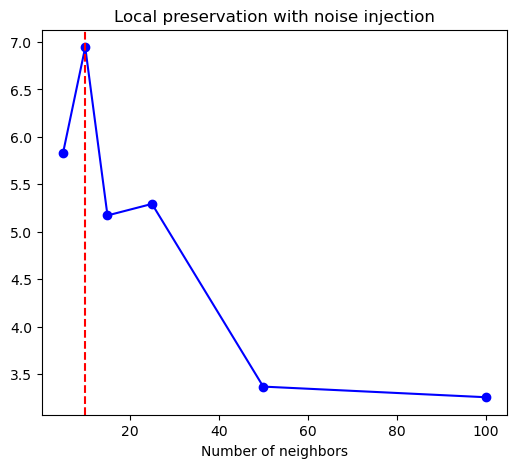

In [ ]:
N = np.random.normal(size=X.shape) 
X_noisy = X + N
pres=[]
for k in neighbor_grid:
Z_lle = LocallyLinearEmbedding(n_components=2, n_neighbors = k, random_state=123).fit_transform(X_noisy)
    pres.append(local_neighborhood_preservation(X, Z_lle, k=20))

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(neighbor_grid, pres, 'bo-')
ax.axvline(neighbor_grid[np.argmax(pres)], linestyle='--', color='red')
ax.set_title('Local preservation with noise injection')
ax.set_xlabel('Number of neighbors')

b) Data subsampling
* Subsample the data 10 times, use 30% of the data on each.
* Fit the manifold embedding on each subsample.
* Compute local-preservation metric. Aggregate the metric to get average local preservation + SE.
* Plot the local preservation metric (with default $k=20$) against neighbor grid values.

In [ ]:
# TODO: Data subsampling fro validation

Text(0.5, 0, 'Number of neighbors')

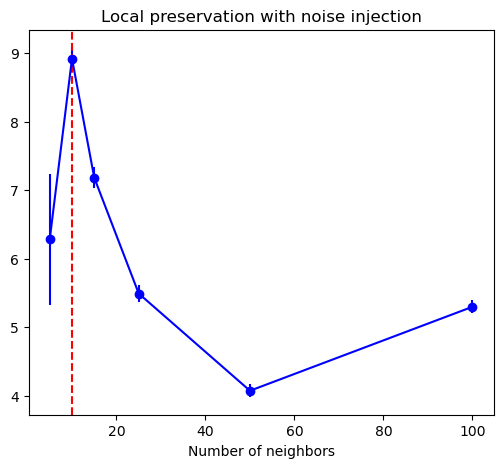

In [363]:
pres=[]
pres_se = []
for k in neighbor_grid:
    pres_sub = []
    for i in range(10):
        sub = np.random.choice(X.shape[0], size = int(np.floor(0.3*X.shape[0])), replace=False)
        X_sub = X[sub,:]
        Z_lle = LocallyLinearEmbedding(n_components=2, n_neighbors = k, random_state=123).fit_transform(X_sub)
        pres_sub.append(local_neighborhood_preservation(X_sub, Z_lle, k=10))
    pres.append(np.mean(pres_sub))
    pres_se.append(np.std(pres_sub)/np.sqrt(10))

fig, ax = plt.subplots(figsize=(6,5))
ax.errorbar(neighbor_grid, pres, fmt='bo-',yerr=pres_se)
ax.axvline(neighbor_grid[np.argmax(pres)], linestyle='--', color='red')
ax.set_title('Local preservation with noise injection')
ax.set_xlabel('Number of neighbors')

3. Propose a way to tune the hyperparameter based on some neighborhood preservation metric inspired by earlier metrics.

In [ ]:
# TODO: Propose a tuning scheme 

Text(0.5, 0, 'Number of neighbors')

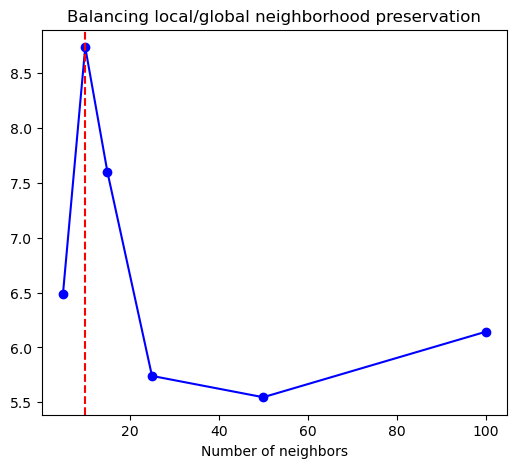

In [369]:
def local_global(X, Z, lambda_val=3.0, k=20):
    global_d = global_distance_preservation(X, Z)
    local_d = local_neighborhood_preservation(X, Z, k)
    return local_d + lambda_val * global_d

pres = []
for k in neighbor_grid:
    Z_lle = LocallyLinearEmbedding(n_components=2, n_neighbors = k, random_state=123).fit_transform(X)
    pres.append(local_global(X, Z_lle))

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(neighbor_grid, pres, 'bo-')
ax.axvline(neighbor_grid[np.argmax(pres)], linestyle='--', color='red')
ax.set_title('Balancing local/global neighborhood preservation')
ax.set_xlabel('Number of neighbors')

4. Conclude

In [ ]:
print(r"$k$=10 seems to be the best hyperparameter for LLE across those 3 validation methods.")

$k$=10 seems to be the best hyperparameter across those 3 validation methods.


# Part III. Application on dataset 


### Question 7. Visualizing data 
On a dataset of your choosing, apply at least two non linear dimension reduction methods to visualize the data. You can use any relevant dataset from the [**UCI repository**](https://archive.ics.uci.edu/) or the *literary_styles_dataset.csv* under the `data/` folder. Make sure that you have at least 20 features in the data and that it is **not** a binary classification task.
Suggested steps: 
1) First, prepare the data appropriately (normalization, scaling etc. if needed). 
2) Observe the PCA embedding for 2 components. 
3) Choose the DR methods based on your assessment of the PCA embedding. 
4) Tune for hyperparameters of your methods. 


In [ ]:
!pip install ucimlrepo #run this if you use a ucimlrepo dataset

In [ ]:
# TODO: load dataset and process it. 

In [ ]:
# TODO: Dimension reduction analysis. 

In [403]:
data = pd.read_csv("../data/literary_styles_dataset.csv")
data.head() 
X_raw, metadata = data.iloc[:, 6:], data.iloc[:, :6]
metadata.head()


,Author,BookID,Title,GutenbergID,BlockID,BlockWords
0,Austen,1,Sense and Sensibility,161,1,1700
1,Austen,1,Sense and Sensibility,161,2,1700
2,Austen,1,Sense and Sensibility,161,3,1700
3,Austen,1,Sense and Sensibility,161,4,1700
4,Austen,1,Sense and Sensibility,161,5,1700


In [408]:
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X_raw)

Text(0.5, 1.0, 'Book title')

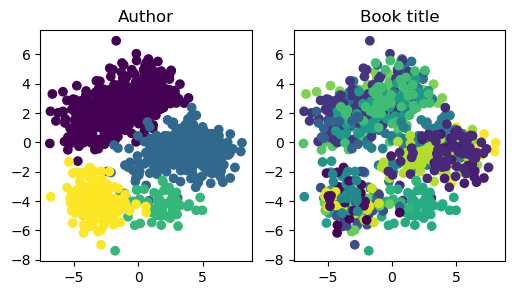

In [ ]:
from sklearn.decomposition import PCA
Z_pca = PCA(n_components=2).fit_transform(X)
fig, ax = plt.subplots(1, 2, figsize=(6,3))
ax[0].scatter(Z_pca[:,0], Z_pca[:, 1], c=metadata['Author'].astype('category').cat.codes)
ax[0].set_title("Author")
ax[1].scatter(Z_pca[:,0], Z_pca[:, 1], c=metadata['Title'].astype('category').cat.codes)
ax[1].set_title("Book title")
# This particular example bas two granularities, using a more local preserving embedding can shed light
# to the specific properties of each book title in the corpus, using a global distance preserving method
# on the other hand like PCA shows that each author's style is already quite well separated linearly.

In [431]:
from sklearn.manifold import TSNE, SpectralEmbedding
perp_grid = np.linspace(15, 70, 5)
neighbor_grid = np.linspace(10, 50, 5, dtype=int)
spec_pres, tsne_pres = [], []
# Tune hyperparameters

for perp in perp_grid:
    Z_tsne = TSNE(n_components=2, perplexity = perp).fit_transform(X)
    tsne_pres.append(local_global(X, Z_tsne, lambda_val = 1))
    
for k in neighbor_grid:
    Z_spec = SpectralEmbedding(n_components=2, n_neighbors= k).fit_transform(X)
    spec_pres.append(local_global(X, Z_spec, lambda_val = 1))

Text(0.5, 1.0, 'Spectral Embedding neighbor param')

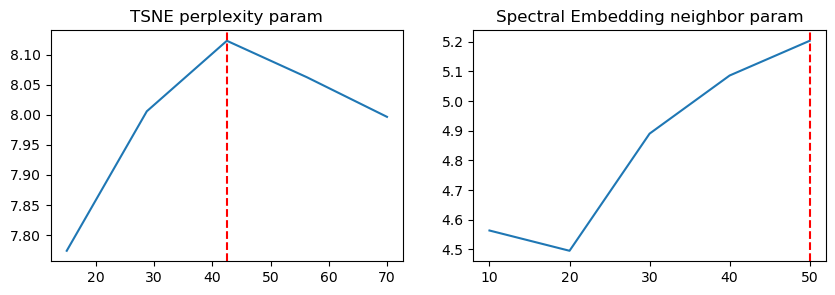

In [432]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(perp_grid, tsne_pres)
ax[0].axvline(perp_grid[np.argmax(tsne_pres)], color='red',linestyle='--')
ax[0].set_title("TSNE perplexity param")
ax[1].plot(neighbor_grid, spec_pres)
ax[1].axvline(neighbor_grid[np.argmax(spec_pres)], color='red',linestyle='--')
ax[1].set_title("Spectral Embedding neighbor param")


In [ ]:
Z_tsne = TSNE(n_components=2, perplexity = perp_grid[np.argmax(tsne_pres)]).fit_transform(X)
Z_spec = SpectralEmbedding(n_components=2, n_neighbors = neighbor_grid[np.argmax(spec_pres)]).fit_transform(X)


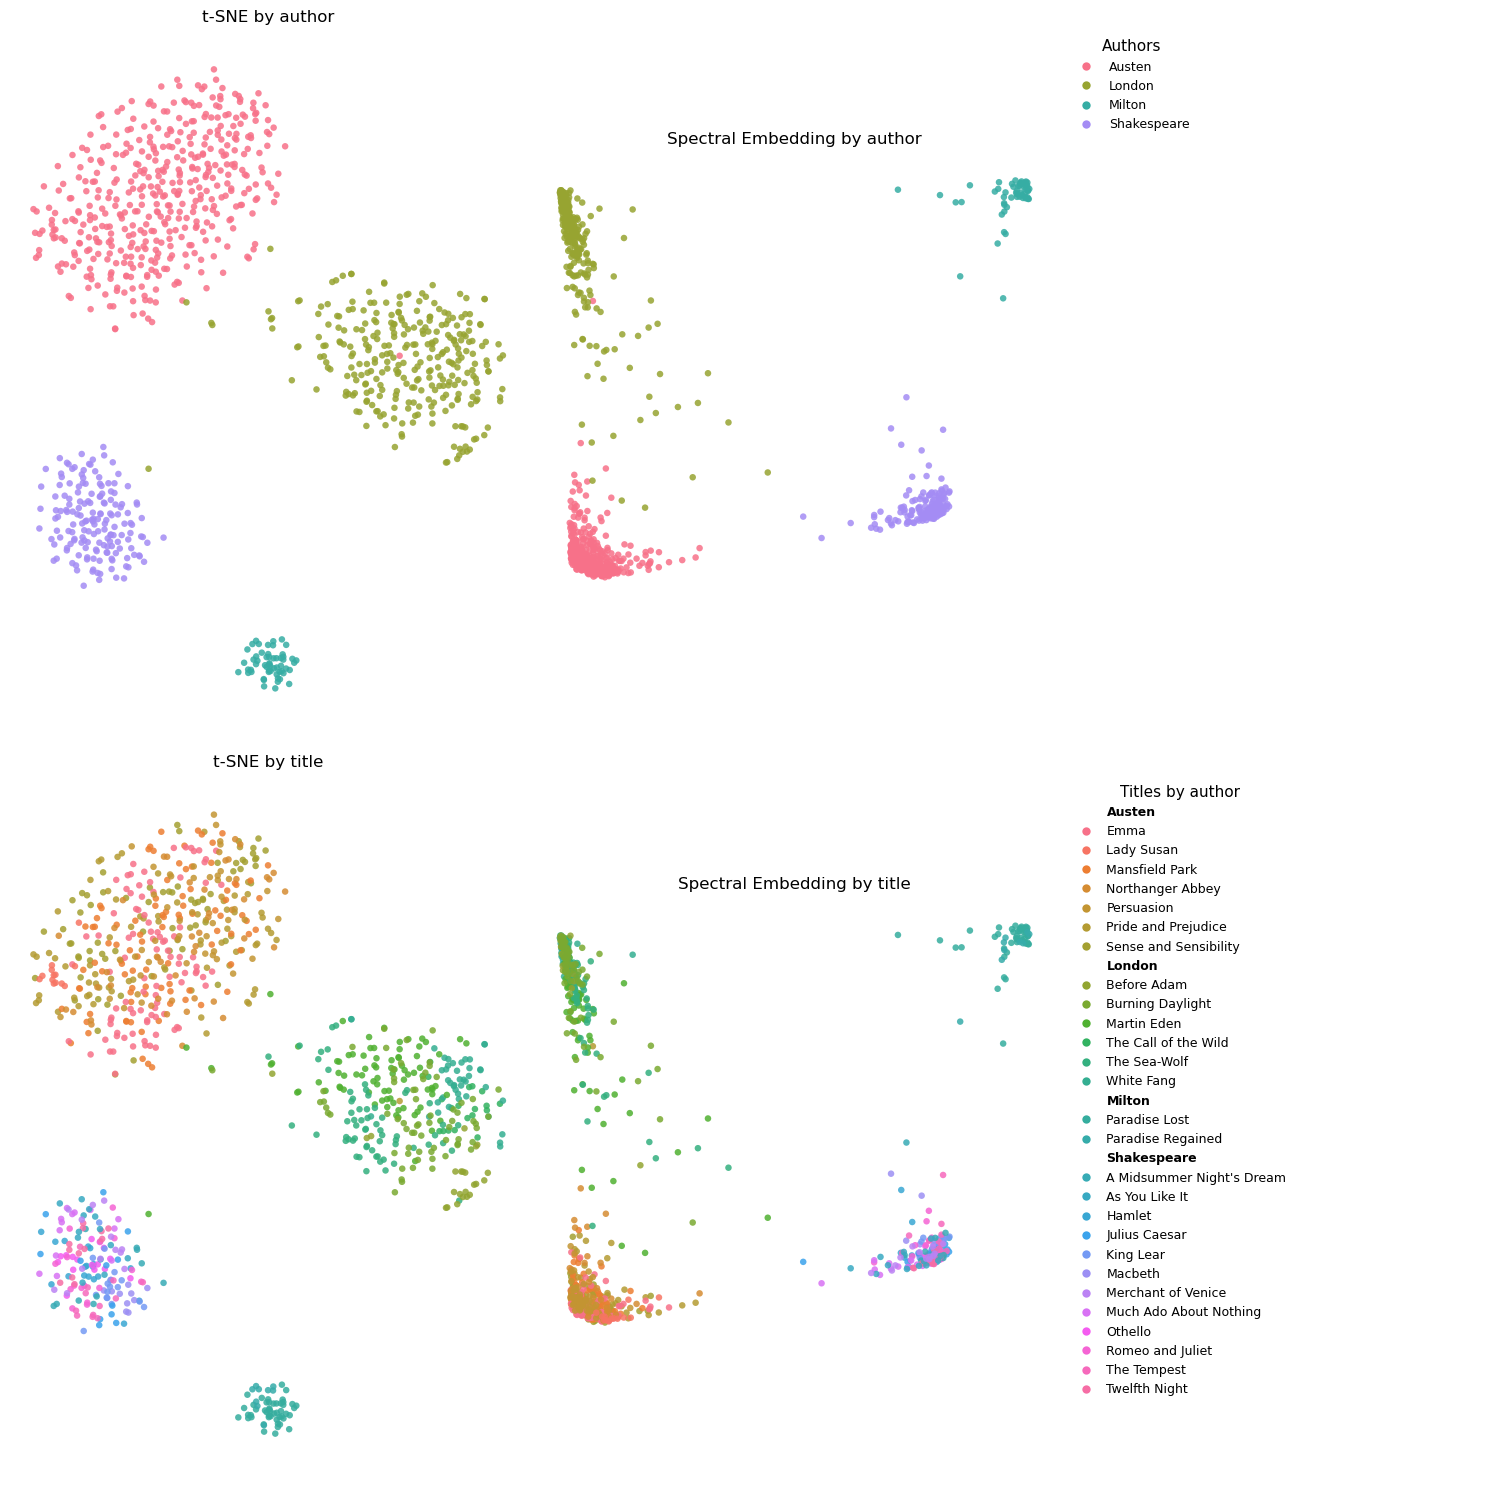

In [464]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

pairs = (metadata[["Author", "Title"]].drop_duplicates().sort_values(["Author", "Title"]))
authors = pairs["Author"].unique()
titles = pairs["Title"].unique()

author_colors = dict(zip(authors, sns.color_palette("husl", len(authors))))
title_colors = dict(zip(titles, sns.color_palette("husl", len(titles))))

def point_colors(column, palette):
    return [palette.get(value, "lightgray") for value in metadata[column]]

def legend_dot(label, color):
    return Line2D([], [], marker="o", linestyle="", markerfacecolor=color, markeredgecolor="none", markersize=6, label=str(label))

# Legend 
title_handles = []
heading_indices = []
for author, group in pairs.groupby("Author", sort=False, observed=True):
    heading_indices.append(len(title_handles))
    title_handles.append(Line2D([], [], linestyle="", label=str(author)))
    title_handles.extend(legend_dot(title, title_colors[title]) for title in group["Title"])
row_height = max(4.5, 0.22 * len(title_handles) + 0.6)


# Figures 
fig = plt.figure(figsize=(15, 2 * row_height), layout="constrained")

gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.85])
ax = np.array([[fig.add_subplot(gs[row, col]) for col in range(2)] for row in range(2)])

legend_axes = [fig.add_subplot(gs[row, 2]) for row in range(2)]
embeddings = [(Z_tsne, "t-SNE"), (Z_spec, "Spectral Embedding")]

for row, (column, palette) in enumerate([("Author", author_colors), ("Title", title_colors)]):
    for col, (Z, name) in enumerate(embeddings):
        axis = ax[row, col]
        axis.scatter(Z[:, 0], Z[:, 1], c=point_colors(column, palette), s=22, alpha=0.85, edgecolors="none")
        axis.set_title(f"{name} by {column.lower()}", fontsize=12, pad=12)
        axis.set_aspect("equal" , adjustable="box")
        axis.axis("off")

for axis in legend_axes:
    axis.axis("off")

legend_axes[0].legend(handles=[legend_dot(a, author_colors[a]) for a in authors], title="Authors", loc="upper left", frameon=False, fontsize=9, title_fontsize=11)
title_legend = legend_axes[1].legend(handles=title_handles, title="Titles by author", loc="upper left", frameon=False, fontsize=9, title_fontsize=11, labelspacing=0.5, handletextpad=0.6)

for index in heading_indices:
    title_legend.get_texts()[index].set_fontweight("bold")

plt.show()

What motivated the choice of method of dimension reduction? Are the visualizations more useful for local neighborhood preservation or global preservation? Does that align with your intuition on the data? 

### Question 8. Scientific discovery with manifold learning

What do you takeaway from the previous visualizations? What would you caution a scientist against while interpreting the embeddings? 

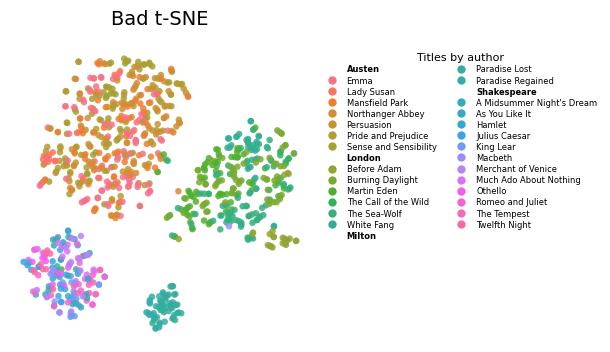

In [462]:
Z_bad = TSNE(n_components=2, perplexity=5).fit_transform(X)

Z, name = Z_bad, "Bad t-SNE"

handles, heading_indices = [], []
for author, group in pairs.groupby("Author", sort=False, observed=True):
    heading_indices.append(len(handles))
    handles.append(Line2D([], [], linestyle="", label=str(author)))

    for title in group["Title"]:
        handles.append(Line2D([], [], marker="o", linestyle="", markerfacecolor=title_colors[title], markeredgecolor="none", markersize=6, label=str(title)))

height = max(3, 0.13 * len(handles) + 1)
fig, ax = plt.subplots(figsize=(6, height), layout="constrained")

ax.scatter(Z[:, 0], Z[:, 1],  c=[title_colors.get(t, "lightgray") for t in metadata["Title"]], s=22, alpha=0.85, edgecolors="none")
ax.set_title(f"{name}", fontsize=14, pad=15)
ax.set_aspect("equal", adjustable="box")
ax.axis("off")

legend = ax.legend(handles=handles, title="Titles by author", bbox_to_anchor=(1.02, 1), loc="upper left", ncols=2, frameon=False, fontsize=6, title_fontsize=8, labelspacing=0.25)

for index in heading_indices:
    legend.get_texts()[index].set_fontweight("bold")

plt.show()

In [463]:
print("We can note that in that case, while the authors' styles separate well, the individual books do not seem to present much local structure. \n" \
        "Even if it did, one should be wary of distortion induced by misguided choice of hyperparameters. For ex, this bad t-SNE distorts the data \n"
        " and might make it seem that the titles do have some sort of structure.  ")

We can note that in that case, while the authors' styles separate well, the individual books do not seem to present much local structure. 
Even if it did, one should be wary of distortion induced by misguided choice of hyperparameters. For ex, this bad t-SNE distorts the data 
 and might make it seem that the titles do have some sort of structure.  


**Run this to create file** 
```{bash} 
python scripts/export_student_notebook.py \
  notebooks/01_dimension_reduction_in_python.ipynb \
  notebooks/01_dimension_reduction_in_python_student.ipynb
```